In [1]:
import numpy as np
import pymc as pm
import matplotlib.pyplot as plt
import arviz as az
from scipy import stats

In [2]:
observations = np.array([134.3, 121.7, 114.1, 135.7, 133.9, 135.7, 146.5, 139.3,
                        133.2, 133.2, 126.0, 111.0, 110.0, 165.0, 154.0, 135.0,
                        154.0, 171.0, 111.1, 138.6, 91.5, 144.1, 140.1,
                        140.3, 125.3, 117.2, 125.3, 133.3, 117.2, 120.0, 105.0,
                        93.0, 106.0, 99.7, 103.3, 101.6])

/home/chaoticneuron/.local/lib/python3.13/site-packages/pymc/distributions/timeseries.py:592: UserWarning: Initial distribution not specified, defaulting to `Normal.dist(0, 100, shape=...)`. You can specify an init_dist manually to suppress this warning.
  warnings.warn(
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [phi, sigma]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 5 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


<Figure size 700x700 with 0 Axes>

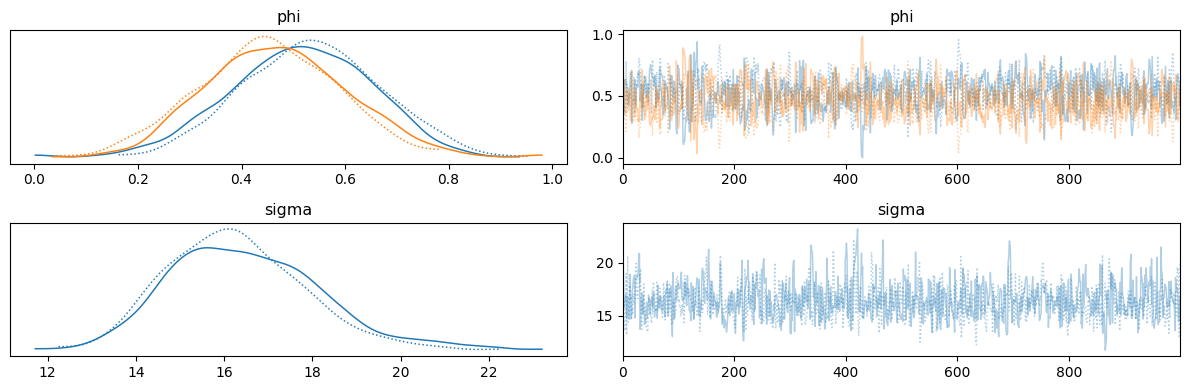

In [28]:
observations = np.array([134.3, 121.7, 114.1, 135.7, 133.9, 135.7, 146.5, 139.3,
                        133.2, 133.2, 126.0, 111.0, 110.0, 165.0, 154.0, 135.0,
                        154.0, 171.0, 111.1, 138.6, 91.5, 144.1, 140.1,
                        140.3, 125.3, 117.2, 125.3, 133.3, 117.2, 120.0, 105.0,
                        93.0, 106.0, 99.7, 103.3, 101.6])
with pm.Model() as bayes_model:
    #priors
    phi = pm.Normal("phi", mu=0, sigma=20, shape=2)
    sigma = pm.Exponential("sigma", lam=1)

    #likelihood
    likelihood = pm.AR("x", phi, sigma, observed=observations)

    #posterior
    trace = pm.sample(1000,cores=2)

plt.figure(figsize=(7,7))
pm.plot_trace(trace)
plt.tight_layout()
plt.show()

In [30]:
import numpy as np
import matplotlib.pyplot as plt

n_forecast = 10
observed = observations

# Extract posterior samples
phi_samples = trace.posterior['phi'].values  # shape (chains, draws, 2)
sigma_samples = trace.posterior['sigma'].values  # shape (chains, draws)

# Combine chains and draws
phi_samples = phi_samples.reshape(-1, 2)
sigma_samples = sigma_samples.flatten()

# Prepare storage for forecasts
forecasts = np.zeros((len(phi_samples), n_forecast))

# Simulate forward
for i, (phi, sigma) in enumerate(zip(phi_samples, sigma_samples)):
    history = list(observed[-2:])  # start from last 2 obs
    for t in range(n_forecast):
        mean = phi[0] * history[-1] + phi[1] * history[-2]
        y_next = np.random.normal(mean, sigma)
        history.append(y_next)
    forecasts[i, :] = history[-n_forecast:]


In [31]:
forecast_mean = forecasts.mean(axis=0)
forecast_hdi = np.percentile(forecasts, [2.5, 97.5], axis=0)

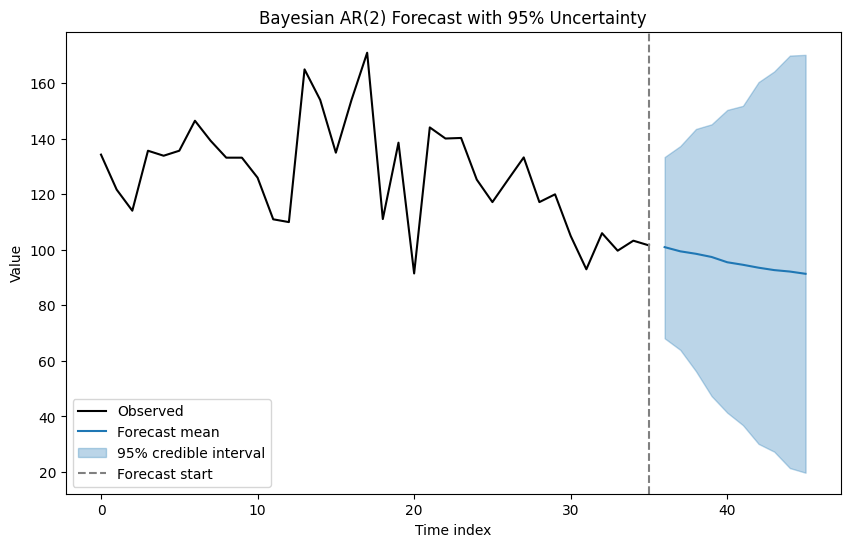

In [32]:
# Combine observed + forecast
x_obs = np.arange(len(observed))
x_forecast = np.arange(len(observed), len(observed) + n_forecast)

plt.figure(figsize=(10, 6))
plt.plot(x_obs, observed, label="Observed", color="black")
plt.plot(x_forecast, forecast_mean, label="Forecast mean", color="tab:blue")
plt.fill_between(x_forecast, forecast_hdi[0], forecast_hdi[1],
                 color="tab:blue", alpha=0.3, label="95% credible interval")

plt.axvline(len(observed)-1, color='gray', linestyle='--', label='Forecast start')
plt.legend()
plt.xlabel("Time index")
plt.ylabel("Value")
plt.title("Bayesian AR(2) Forecast with 95% Uncertainty")
plt.show()


In [47]:
years = x_obs + 1989
years = np.append(years, (x_forecast + 1989)).flatten()

In [51]:
annual_means = np.append(observed,forecast_mean)
annual_means

array([134.3       , 121.7       , 114.1       , 135.7       ,
       133.9       , 135.7       , 146.5       , 139.3       ,
       133.2       , 133.2       , 126.        , 111.        ,
       110.        , 165.        , 154.        , 135.        ,
       154.        , 171.        , 111.1       , 138.6       ,
        91.5       , 144.1       , 140.1       , 140.3       ,
       125.3       , 117.2       , 125.3       , 133.3       ,
       117.2       , 120.        , 105.        ,  93.        ,
       106.        ,  99.7       , 103.3       , 101.6       ,
       100.97950911,  99.46978846,  98.58201123,  97.43318941,
        95.53168934,  94.62160829,  93.57132629,  92.70749238,
        92.18535307,  91.37393307])

In [49]:
forecast_mean

array([100.97950911,  99.46978846,  98.58201123,  97.43318941,
        95.53168934,  94.62160829,  93.57132629,  92.70749238,
        92.18535307,  91.37393307])

In [78]:
stds = np.zeros(36)
for i in range(0,10):
    std= forecasts[:,i].std()
    stds = np.append(stds,std)

In [84]:
import pandas as pd
df = pd.DataFrame(years.flatten(),annual_means.flatten()).reset_index()

In [86]:
df.columns=['annual_mean','year']

In [81]:
stds.shape

(46,)

In [88]:
df['SD'] = stds

In [90]:
df.to_csv('BayesianAR2Forecasts.csv',index=False)